# Khám phá dữ liệu Netflix

## 1. Giới thiệu

### 1.1. Mục tiêu phân tích
Tìm ra các xu hướng đang thể hiện trong bộ dữ liệu nội dung của Netflix (netflix_titles.csv), từ đó rút ra insight về cách Netflix xây dựng danh mục nội dung theo thời gian, thể loại, khu vực.

### 1.2. Câu hỏi phân tích
1. Loại nội dung nào (Movie/TV Show) chiếm đa số?
2. Phân bố thời lượng của Movie và TV Show ra sao?
3. Rating nào phổ biến nhất?
4. Năm nào Netflix "bùng nổ" về số lượng nội dung thêm mới?
5. Thể loại nào thường được Netflix thêm vào nhiều nhất theo từng tháng trong năm? (tính mùa vụ, dựa trên `date_added`)
6. Top 10 đạo diễn có nhiều nội dung nhất?
7. Quốc gia nào có nhiều nội dung nhất?
8. Từ khóa phổ biến nhất trong mô tả là gì?

### 1.3. Mô tả bộ dữ liệu
- Loại dữ liệu: One big table

## 2. Chuẩn bị

### 2.1. Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

pd.set_option('display.max_columns', None) #cho phép pd hiển thị tất cả các cột dataframe
pd.set_option('display.float_format', '{:.2f}'.format) #chỉ lấy 2 dấu phẩy sau chữ số thập phân

# Bảng màu dùng chung cho toàn bộ biểu đồ (categorical: xanh dương -> cam -> xanh ngọc...)
PALETTE = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
SURFACE, INK, MUTED, GRID = '#fcfcfb', '#0b0b0b', '#898781', '#e1e0d9'
plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'axes.edgecolor': GRID, 'axes.labelcolor': INK, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.grid': True,
    'grid.color': GRID, 'grid.linewidth': 0.8, 'axes.spines.top': False,
    'axes.spines.right': False, 'font.size': 10,
})

### 2.2. Load dữ liệu

In [2]:
df = pd.read_csv('./netflix_titles.csv')  #đọc dữ liệu từ file csv

## 3. Tổng quan dữ liệu

### 3.1. Kích thước dữ liệu trước khi làm sạch

In [3]:
shape_before = df.shape
shape_before  # (số dòng, số cột)

(8807, 12)

### 3.2. Kiểu dữ liệu của từng cột

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


## 4. Làm sạch dữ liệu

### 4.1. Dữ liệu bị thiếu

#### 4.1.1. Thống kê số dòng & % thiếu

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_rows': missing, 'pct': missing_pct}).sort_values('missing_rows', ascending=False)

,missing_rows,pct
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03
show_id,0,0.00
type,0,0.00
title,0,0.00
release_year,0,0.00


#### Soi kỹ các cột có ít null (*)

Bảng 4.1.1 cho thấy `rating` thiếu 4 ô và `duration` thiếu 3 ô. Đây là 2 cột bắt buộc nhưng chỉ thiếu vài ô thì thường không phải "thiếu tự nhiên" nên cần kiểm ra thêm.

-> in ra **toàn bộ** để kiểm tra từng dòng một:

In [6]:
# Lấy các cột có ít null (0 < null <= 5) rồi in HẾT những dòng dính null ở các cột đó
null_cell_check = missing[(missing > 0) & (missing <= 5)].index.tolist()
print('Cột có ít null:', null_cell_check)

mask_it_null = df[null_cell_check].isnull().any(axis=1)
display(df.loc[mask_it_null, ['show_id', 'type', 'title', 'rating', 'duration']])

Cột có ít null: ['rating', 'duration']


,show_id,type,title,rating,duration
5541,s5542,Movie,Louis C.K. 2017,74 min,NaN
5794,s5795,Movie,Louis C.K.: Hilarious,84 min,NaN
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,66 min,NaN
5989,s5990,Movie,13TH: A Conversation with Oprah Winfrey & Ava ...,NaN,37 min
6827,s6828,TV Show,Gargantia on the Verdurous Planet,NaN,1 Season
7312,s7313,TV Show,Little Lunch,NaN,1 Season
7537,s7538,Movie,My Honor Was Loyalty,NaN,115 min


**Nhận xét:** 7 dòng trên tách thành 2 nhóm:
- **3 dòng thiếu giả**: `rating` đang chứa dữ liệu của `duration` (`"74 min"`, `"84 min"`, `"66 min"`) còn `duration` thì trống. Cả 3 cùng một nghệ sĩ → lỗi của một lô dữ liệu, không ngẫu nhiên.

#### 4.1.2. Điền "Unknown": director, cast, country

In [7]:
# Điền giá trị 'Unknown' cho các cột có nhiều null (null > 5) để tránh mất dữ liệu
for col in ['director', 'cast', 'country']:
    df[col] = df[col].fillna('Unknown')

#### 4.1.3. Xoá dòng thiếu: date_added, rating, duration


In [8]:
# (thời gian, rating, thời lượng) -> xoá dòng thiếu không ảnh hưởng đáng kể tới toàn bộ dữ liệu
before = len(df)
df = df.dropna(subset=['date_added', 'rating', 'duration'])
after = len(df)
print(f'Số dòng bị xoá: {before - after} (còn lại {after} dòng)')

Số dòng bị xoá: 17 (còn lại 8790 dòng)


#### 4.1.4. Kiểm tra lại sau khi xử lý

In [9]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

### 4.2. Dữ liệu trùng lặp (*)

Chạy phép kiểm chuẩn, kiểm chứng xem `show_id` có đúng là khoá duy nhất không, rồi bỏ nó ra để kiểm tra trùng theo nội dung thật.

In [10]:
print('Trùng toàn bộ dòng:', df.duplicated().sum())
print('Trùng nội dung (bỏ show_id):', df.duplicated(subset=df.columns.difference(['show_id'])).sum()) # khác ID nhưng trùng toàn bộ tt khác

Trùng toàn bộ dòng: 0
Trùng nội dung (bỏ show_id): 0


### 4.3. Chuẩn hóa định dạng

#### 4.3.1. date_added: chuyển sang datetime

Mục 3.2 cho thấy `date_added` đang là chuỗi, mục 3.3 cho thấy dạng `"September 25, 2021"` → thử parse thẳng với format `%B %d, %Y`.

In [11]:
try:
    pd.to_datetime(df['date_added'], format='%B %d, %Y')
except ValueError as e:
    print('ValueError:', str(e).split('. You might')[0])

ValueError: time data " August 4, 2017" doesn't match format "%B %d, %Y"


Parse thất bại. Thông báo lỗi chỉ đúng chuỗi gây lỗi: `" August 4, 2017"` — dấu nháy kép cho thấy có **khoảng trắng thừa ở đầu** chuỗi, nên không khớp format.`.str.strip()` trước khi parse lại.

In [12]:
df['date_added'] != df['date_added'].str.strip()

df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), format='%B %d, %Y')
print('Khoảng thời gian date_added:', df['date_added'].min(), '->', df['date_added'].max())

Khoảng thời gian date_added: 2008-01-01 00:00:00 -> 2021-09-25 00:00:00


#### 4.3.2. duration: tách thành số + đơn vị

Mục 3.3 cho thấy `duration` gộp 2 thứ trong 1 ô: phần số và phần đơn vị (`min` / `Season` / `Seasons`). Tách ra 2 cột riêng, đọc đơn vị trực tiếp từ chuỗi (không suy từ `type`), và gom `Season`/`Seasons` về cùng một nhãn.

In [13]:
# Tách phần số và phần chữ ra 2 cột; 'Season'/'Seasons' gom về 'season'
df['duration_value'] = df['duration'].str.extract(r'(\d+)').astype(int)
df['duration_unit'] = df['duration'].str.extract(r'\d+\s*(.*)')[0].str.strip().str.lower().str.rstrip('s')

print(df['duration_unit'].value_counts())
df[['type', 'duration', 'duration_value', 'duration_unit']].sample(5, random_state=1)

duration_unit
min       6126
season    2664
Name: count, dtype: int64


,type,duration,duration_value,duration_unit
7248,Movie,52 min,52,min
6015,Movie,86 min,86,min
6966,Movie,96 min,96,min
6709,TV Show,1 Season,1,season
6602,Movie,123 min,123,min


### 4.4. Kiểm tra logic & nhất quán (*)

#### 4.4.1. date_added so với release_year

Về logic, ngày thêm vào Netflix (`date_added`) phải sau năm phát hành (`release_year`). Kiểm tra các dòng vi phạm.

In [14]:
mask_logic = df['date_added'].dt.year < df['release_year']
print('Số dòng có date_added (năm) nhỏ hơn release_year:', mask_logic.sum())
print(df.loc[mask_logic, 'type'].value_counts())
print()
df.loc[mask_logic, ['title', 'type', 'release_year', 'date_added']].sort_values('type')

Số dòng có date_added (năm) nhỏ hơn release_year: 14
type
TV Show    12
Movie       2
Name: count, dtype: int64



,title,type,release_year,date_added
5394,Hans Teeuwen: Real Rancour,Movie,2018,2017-07-01
7063,Incoming,Movie,2019,2018-10-26
1551,Hilda,TV Show,2021,2020-12-14
1696,Polly Pocket,TV Show,2021,2020-11-15
2920,Love Is Blind,TV Show,2021,2020-02-13
3168,Fuller House,TV Show,2020,2019-12-06
3287,Maradona in Mexico,TV Show,2020,2019-11-13
3369,BoJack Horseman,TV Show,2020,2019-10-25
3433,The Hook Up Plan,TV Show,2020,2019-10-11
4844,Unbreakable Kimmy Schmidt,TV Show,2019,2018-05-30


**Nhận xét:** 14 dòng vi phạm gồm 12 `TV Show` và **2 `Movie`**:

- **12 dòng TV Show:** `release_year` trong bộ dữ liệu này thường là năm phát hành **mùa gần nhất**, trong khi `date_added` là ngày Netflix thêm **mùa đầu tiên**, nên `date_added` sớm hơn `release_year` một cách hợp lý.
- **2 dòng Movie:** với Movie không có khái niệm "mùa" nên lý do trên không áp dụng được **chưa xác minh được nguyên nhân**.

### 4.5. Outlier (*)

#### 4.5.1. Thời lượng Movie

Ngưỡng IQR: [46, 154] phút | Số outlier: 449 (7.3%)


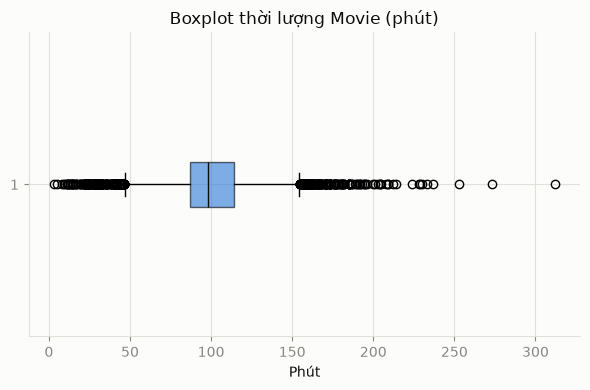

In [15]:
movie_dur = df.loc[df['type'] == 'Movie', 'duration_value']
q1, q3 = movie_dur.quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = movie_dur[(movie_dur < low) | (movie_dur > high)]
print(f'Ngưỡng IQR: [{low:.0f}, {high:.0f}] phút | Số outlier: {len(outliers)} ({len(outliers)/len(movie_dur)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(movie_dur, orientation='horizontal', patch_artist=True,
           boxprops=dict(facecolor=PALETTE[0], alpha=0.6), medianprops=dict(color=INK))
ax.set_title('Boxplot thời lượng Movie (phút)')
ax.set_xlabel('Phút')
plt.tight_layout()
plt.show()

**Nhận xét:** khoảng 7% phim nằm ngoài ngưỡng IQR (phim rất ngắn hoặc rất dài), nhưng đây là **giá trị thật** (phim ngắn, phim tài liệu dài...), không phải lỗi nhập liệu -> **không xoá**, chỉ ghi nhận khi phân tích về phân bố. 

#### 4.5.2. Số mùa TV Show

count   2664.00
mean       1.75
std        1.55
min        1.00
25%        1.00
50%        1.00
75%        2.00
max       17.00
Name: duration_value, dtype: float64


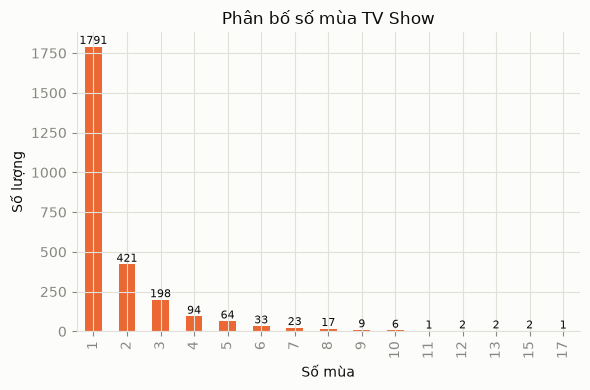

In [16]:
tv_season = df.loc[df['type'] == 'TV Show', 'duration_value']
print(tv_season.describe())

fig, ax = plt.subplots(figsize=(6, 4))
tv_season.value_counts().sort_index().plot(kind='bar', color=PALETTE[1], ax=ax)
ax.bar_label(ax.containers[0], fontsize=8)
ax.set_title('Phân bố số mùa TV Show')
ax.set_xlabel('Số mùa')
ax.set_ylabel('Số lượng')
plt.tight_layout()
plt.show()

**Nhận xét:** phần lớn TV Show chỉ có 1 mùa (phân phối lệch phải mạnh); một số ít show có 15–17 mùa là giá trị thật (show dài kỳ, vd sitcom/reality lâu năm).

### 4.6. Mã hóa lại dữ liệu

#### 4.6.1. Tìm các cột chứa nhiều giá trị trong 1 ô

Mục 3.2 cho thấy phần lớn các cột là chuỗi (`str`). Xem vài dòng mẫu của các cột chuỗi dài, rồi đo tỷ lệ dòng có dấu phẩy ở từng cột chuỗi để biết cột nào đang gộp nhiều giá trị.

In [17]:
display(df[['title', 'director', 'cast', 'country', 'listed_in', 'description']].head(5))

# Tỷ lệ % dòng có dấu phẩy ở từng cột chuỗi
text_cols = [c for c in df.columns if pd.api.types.is_string_dtype(df[c])]
ty_le_phay = pd.Series({c: df[c].str.contains(',').mean() * 100 for c in text_cols}).round(1)
ty_le_phay.sort_values(ascending=False)

,title,director,cast,country,listed_in,description
0,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,Documentaries,"As her father nears the end of his life, filmm..."
1,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,Jailbirds New Orleans,Unknown,Unknown,Unknown,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


cast            80.60
listed_in       77.10
description     73.20
country         15.00
director         7.00
title            1.60
show_id          0.00
type             0.00
rating           0.00
duration         0.00
duration_unit    0.00
dtype: float64

In [18]:
# title và description cũng có dấu phẩy — xem thử dấu phẩy ở đó là danh sách hay chỉ là câu văn
df.loc[df['title'].str.contains(','), 'title'].head(5).tolist()

['Vendetta: Truth, Lies and The Mafia',
 'El patrón, radiografía de un crimen',
 'LSD: Love, Sex Aur Dhokha',
 'Bob Ross: Happy Accidents, Betrayal & Greed',
 'Nevertheless,']

**Nhận xét:** 6 cột chuỗi có dấu phẩy, nhưng chia làm 2 loại:

- `cast`, `listed_in`, `country`, `director`: dấu phẩy **ngăn cách các giá trị** (vd `"International TV Shows, TV Dramas, TV Mysteries"`) → một ô chứa nhiều thể loại / diễn viên / quốc gia / đạo diễn. Nếu đếm nguyên chuỗi, `"United States, India"` sẽ bị tính là một "quốc gia" riêng → **cần tách** trước khi đếm.
- `title`, `description`: dấu phẩy chỉ là **dấu câu** trong văn bản (vd `"Vendetta: Truth, Lies and The Mafia"`) → không tách.

#### 4.6.2. Tách 4 cột nhiều giá trị

Tách `listed_in`, `country`, `director`, `cast` theo `', '` để mỗi dòng chỉ còn 1 giá trị, dùng cho các câu hỏi đếm theo thể loại / quốc gia / đạo diễn ở mục 6.

In [19]:
MULTI_COLS = ['listed_in', 'country', 'director', 'cast']

for col in MULTI_COLS:
    labels = df[col].str.split(', ').explode()
    print(f'{col}: {labels.nunique()} giá trị khác nhau')

listed_in: 42 giá trị khác nhau
country: 128 giá trị khác nhau
director: 4992 giá trị khác nhau
cast: 36393 giá trị khác nhau


#### 4.6.3. Gom nhóm rating theo độ tuổi (*)

14 mã rating thuộc 2 hệ thống của Mỹ: MPA cho phim (G, PG, PG-13, R, NC-17) và TV Parental Guidelines cho chương trình TV (TV-Y, TV-Y7, TV-Y7-FV, TV-G, TV-PG, TV-14, TV-MA). Gom theo 3 mức mà Netflix dùng cho thị trường Mỹ (Netflix Help Center — *Maturity ratings for TV shows and movies on Netflix*):

| Nhóm | Mã rating |
|---|---|
| Kids | TV-Y, TV-Y7, TV-Y7-FV, G, TV-G, PG, TV-PG |
| Teens | PG-13, TV-14 |
| Adults | R, NC-17, TV-MA |
| Not Rated | NR, UR (chưa được phân loại) |

`TV-Y7-FV` không có trong bảng của Netflix; đây là biến thể của `TV-Y7` nên xếp cùng nhóm Kids.

In [20]:
RATING_GROUP = {
    'TV-Y': 'Kids', 'TV-Y7': 'Kids', 'TV-Y7-FV': 'Kids', 'G': 'Kids', 'TV-G': 'Kids', 'PG': 'Kids', 'TV-PG': 'Kids',
    'PG-13': 'Teens', 'TV-14': 'Teens',
    'R': 'Adults', 'NC-17': 'Adults', 'TV-MA': 'Adults',
    'NR': 'Not Rated', 'UR': 'Not Rated',
}

# Kiểm tra dict có phủ hết giá trị rating thật không — thiếu 1 mã thì .map() lặng lẽ trả NaN
chua_map = set(df['rating'].unique()) - set(RATING_GROUP)
print('Mã rating chưa được gom nhóm:', chua_map if chua_map else 'không có')

df['rating_group'] = df['rating'].map(RATING_GROUP)
print('Số dòng bị NaN sau khi map:', df['rating_group'].isna().sum())
df['rating_group'].value_counts(dropna=False)

Mã rating chưa được gom nhóm: không có
Số dòng bị NaN sau khi map: 0


rating_group
Adults       4007
Teens        2647
Kids         2054
Not Rated      82
Name: count, dtype: int64

### 4.7. Tổng kết trước / sau khi làm sạch

In [21]:
summary = pd.DataFrame({
    'before': [shape_before[0], shape_before[1], missing['rating'], missing['duration'], missing['date_added'],
               missing['director'], missing['cast'], missing['country']],
    'after':  [len(df), df.shape[1], 0, 0, 0, 0, 0, 0],
}, index=['rows', 'columns', 'missing_rating', 'missing_duration', 'missing_date_added',
          'missing_director', 'missing_cast', 'missing_country'])
summary

,before,after
rows,8807,8790
columns,12,15
missing_rating,4,0
missing_duration,3,0
missing_date_added,10,0
missing_director,2634,0
missing_cast,825,0
missing_country,831,0


## 5. Feature Engineering

### 5.1. Tạo cột description_length

In [22]:
df['description_length'] = df['description'].str.len()
df['description_length'].describe()

count   8790.00
mean     143.30
std       10.34
min       61.00
25%      140.00
50%      146.00
75%      149.00
max      248.00
Name: description_length, dtype: float64

### 5.2. Tách ngày / tháng / năm từ date_added

In [23]:
df['added_year'] = df['date_added'].dt.year
df['added_month'] = df['date_added'].dt.month
df['added_day'] = df['date_added'].dt.day
df[['date_added', 'added_year', 'added_month', 'added_day']].head()

,date_added,added_year,added_month,added_day
0,2021-09-25,2021,9,25
1,2021-09-24,2021,9,24
2,2021-09-24,2021,9,24
3,2021-09-24,2021,9,24
4,2021-09-24,2021,9,24


### 5.3. Loại bỏ cột không cần thiết

In [24]:
# Cột duration (chuỗi gốc) đã được thay thế bởi duration_value + duration_unit ở mục 4.3.2 nên không cần giữ lại
df = df.drop(columns=['duration'])
df.columns.tolist()

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'listed_in',
 'description',
 'duration_value',
 'duration_unit',
 'rating_group',
 'description_length',
 'added_year',
 'added_month',
 'added_day']

## 6. Phân tích khám phá (EDA)

### 6.1. Loại nội dung nào chiếm đa số trên Netflix?

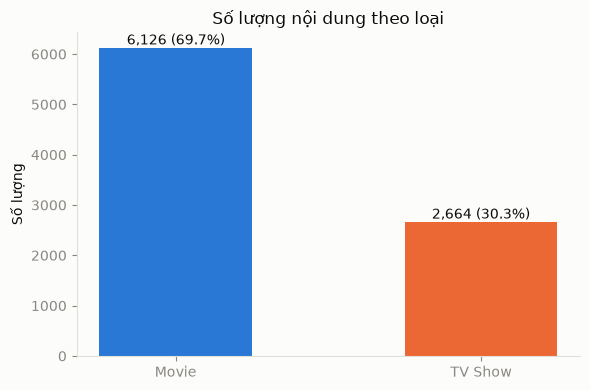

In [25]:
counts = df['type'].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values, color=PALETTE[:2], width=0.5)
for b in bars:
    h = b.get_height()
    ax.annotate(f'{h:,} ({h / counts.sum() * 100:.1f}%)', (b.get_x() + b.get_width()/2, h),
                ha='center', va='bottom')
ax.grid(False)  # tắt lưới (ô import ở đầu notebook đang bật lưới cho mọi biểu đồ)
ax.set_title('Số lượng nội dung theo loại')
ax.set_ylabel('Số lượng')
plt.tight_layout()
plt.show()


**Insight:** Trong kho nội dung của Netflix, Movie chiếm đa số với 6.126 tiêu đề (~70%), gấp khoảng 2,3 lần TV Show (2.664 tiêu đề, ~30%). Như vậy danh mục của Netflix nghiêng rõ về số lượng phim lẻ.

### 6.2. Phân bố thời lượng của Movie và TV Show

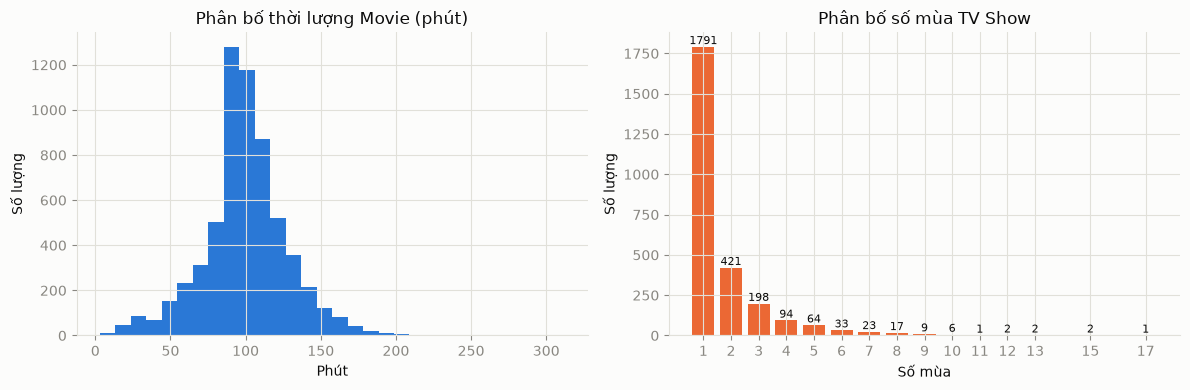

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df.loc[df['type'] == 'Movie', 'duration_value'], bins=30, color=PALETTE[0])
axes[0].set_title('Phân bố thời lượng Movie (phút)')
axes[0].set_xlabel('Phút')
axes[0].set_ylabel('Số lượng')

seasons = (df.loc[df['type'] == 'TV Show', 'duration_value']
             .astype(int)
             .value_counts()
             .sort_index())
bars = axes[1].bar(seasons.index, seasons.values, color=PALETTE[1])
axes[1].bar_label(bars, fontsize=8)
axes[1].set_xticks(seasons.index)
axes[1].set_title('Phân bố số mùa TV Show')
axes[1].set_xlabel('Số mùa')
axes[1].set_ylabel('Số lượng')

plt.tight_layout()
plt.show()

**Insight:** 

- **Movie**: thời lượng tập trung ở khoảng 90–110 phút, phân bố gần dạng chuông và hơi lệch phải. Phần lớn phim nằm trong khoảng 60–150 phút, đúng với độ dài chuẩn của một phim điện ảnh.

- **TV Show**: phân bố lệch phải mạnh. Khoảng 2/3 series (~1.790) chỉ có 1 mùa, khoảng 16% có 2 mùa, và số lượng giảm nhanh từ mùa thứ 3 trở đi. Chỉ rất ít series kéo dài hơn 5 mùa. Điều này cho thấy kho series của Netflix chủ yếu là series ngắn.

### 6.3. Rating nào phổ biến nhất?

rating
TV-MA   0.36
TV-14   0.25
TV-PG   0.10
Name: proportion, dtype: float64
0.06450511945392491


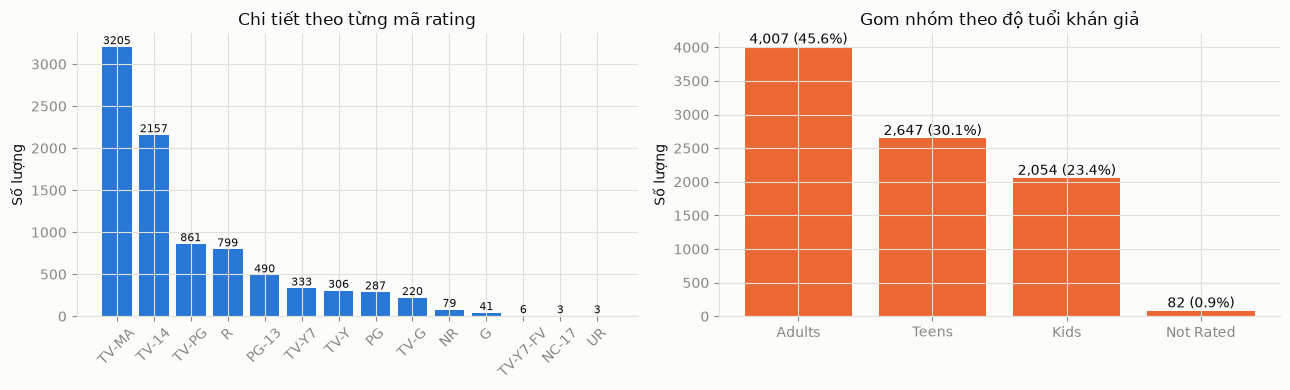

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

rc = df['rating'].value_counts()
bars = axes[0].bar(rc.index, rc.values, color=PALETTE[0])
axes[0].bar_label(bars, fontsize=8)
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_title('Chi tiết theo từng mã rating')
axes[0].set_ylabel('Số lượng')

# Dùng rating_group đã gom ở mục 4.6.3 — 14 mã rating rời rạc khó đọc thành kết luận về nhóm khán giả
rg = df['rating_group'].value_counts()
bars = axes[1].bar(rg.index, rg.values, color=PALETTE[1])
for b, v in zip(bars, rg.values):
    axes[1].annotate(f'{v:,} ({v/len(df)*100:.1f}%)', (b.get_x() + b.get_width()/2, b.get_height()),
                     ha='center', va='bottom')
axes[1].set_title('Gom nhóm theo độ tuổi khán giả')
axes[1].set_ylabel('Số lượng')

print(df['rating'].value_counts(normalize=True).head(3))
print(df['rating'].isin(['TV-Y', 'TV-G', 'G']).mean())

plt.tight_layout()
plt.show()

**Insight:** Rating phổ biến nhất là `TV-MA` (36%), tiếp theo là `TV-14` (25%) và `TV-PG` (10%). Riêng hai mã đầu đã chiếm hơn một nửa kho nội dung. Khi gom theo các mức độ tuổi của Netflix (mục 4.6.3), nội dung cho `Adults` chiếm 45,6%, gần bằng `Teens` (30,1%) và `Kids` (23,4%) cộng lại. Kho nội dung của Netflix nghiêng rõ về khán giả trưởng thành. Trong nhóm `Kids`, phần lớn là nội dung cần phụ huynh hướng dẫn (`PG`/`TV-PG`), còn nội dung dành cho trẻ nhỏ (`TV-Y`, `TV-G`, `G`) chỉ chiếm 6,5% toàn bộ kho. Nội dung chưa phân loại (0,9%) không đáng kể.

### 6.4. Năm "bùng nổ" của Netflix là năm nào?

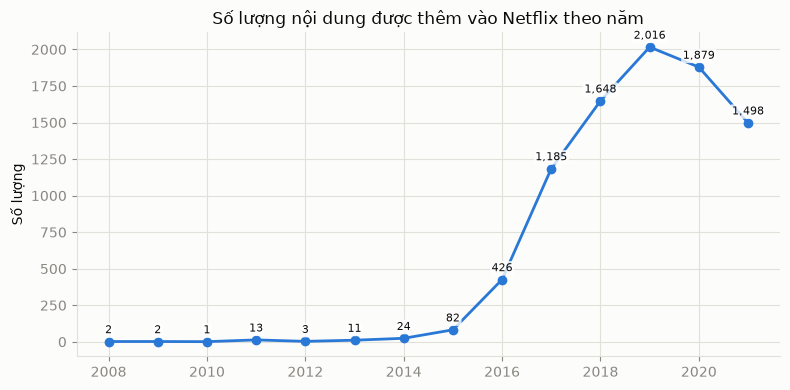

In [28]:
by_year = df['added_year'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(by_year.index, by_year.values, color=PALETTE[0], marker='o', linewidth=2)
for x, y in by_year.items():
    ax.annotate(f'{y:,}', (x, y), textcoords='offset points', xytext=(0, 6),
                ha='center', fontsize=8,
                   bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.8))
ax.set_title('Số lượng nội dung được thêm vào Netflix theo năm')
ax.set_ylabel('Số lượng')
plt.tight_layout()
plt.show()

**Insight:** Trước năm 2015, Netflix gần như không bổ sung nội dung vào kho này (tổng cộng 56 tiêu đề trong 7 năm). Từ 2016, số lượng tăng vọt: gấp khoảng 5 lần so với 2015, rồi tiếp tục tăng mạnh đến đỉnh **2.016 tiêu đề năm 2019**. Giai đoạn 2016–2021 chiếm **98,4%** toàn bộ nội dung. Năm 2020 giảm nhẹ 6,8% so với đỉnh. Một giả thuyết là ảnh hưởng của COVID-19 lên hoạt động sản xuất, nhưng dữ liệu này không kiểm chứng được nguyên nhân. Năm 2021 chỉ có dữ liệu đến tháng 9, nên điểm giảm xuống 1.498 trên biểu đồ **không phản ánh xu hướng thật**. Riêng năm 2021, dữ liệu chỉ tính đến tháng 9: trong 9 tháng Netflix đã bổ sung 1.498 tiêu đề, quy về bình quân khoảng 166 tiêu đề/tháng, cao hơn năm 2020 (157) và gần bằng đỉnh 2019 (168). Dù chưa có số liệu cả năm, tốc độ bổ sung nội dung năm 2021 không giảm; đoạn đi xuống trên biểu đồ chủ yếu do thiếu 3 tháng cuối năm.

### 6.5. Thể loại nào phù hợp phát hành vào tháng nào? (tính mùa vụ)

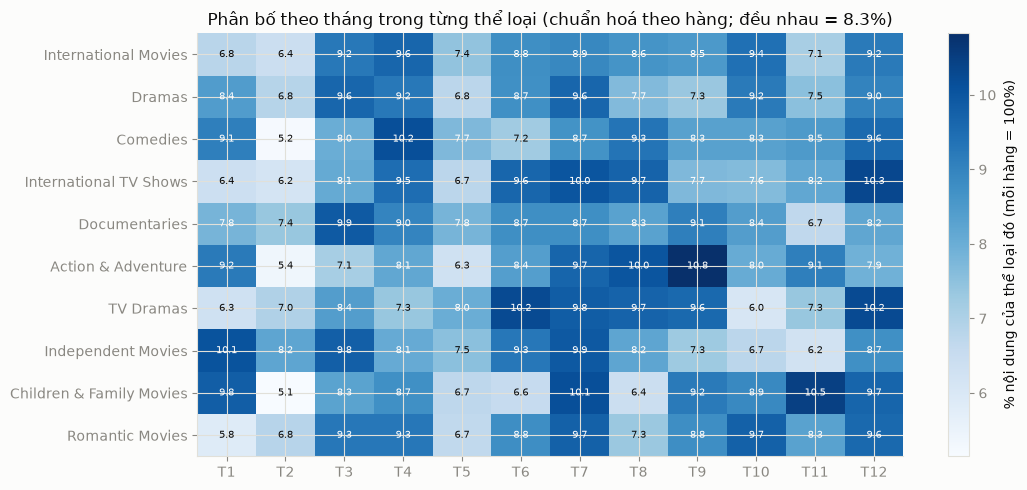

                          peak_month  max_pct  min_pct  spread_pct
genre                                                             
International Movies               4     9.60     6.40        3.20
Dramas                             3     9.60     6.80        2.90
Comedies                           4    10.20     5.20        5.00
International TV Shows            12    10.30     6.20        4.20
Documentaries                      3     9.90     6.70        3.20
Action & Adventure                 9    10.80     5.40        5.50
TV Dramas                          6    10.20     6.00        4.20
Independent Movies                 1    10.10     6.20        3.80
Children & Family Movies          11    10.50     5.10        5.30
Romantic Movies                    7     9.70     5.80        3.90


In [29]:
genres = df.assign(genre=df['listed_in'].str.split(', ')).explode('genre')
top_genres = genres['genre'].value_counts().head(10).index.tolist()
pivot = (genres[genres['genre'].isin(top_genres)]
         .pivot_table(index='genre', columns='added_month', values='show_id', aggfunc='count', fill_value=0)
         .reindex(top_genres))

# Heatmap trên SỐ ĐẾM THÔ không trả lời được câu hỏi mùa vụ: thể loại nhiều nội dung (International Movies)
# sẽ đậm màu ở mọi tháng, thể loại ít nội dung nhạt màu ở mọi tháng -> chỉ thấy "thể loại nào lớn",
# không thấy "trong CÙNG một thể loại, tháng nào nổi trội".
# => chuẩn hoá theo hàng: mỗi hàng cộng lại = 100%, so với mốc đều nhau 100/12 = 8.3%/tháng.
row_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(row_pct.values, cmap='Blues', aspect='auto')
ax.set_xticks(range(12))
ax.set_xticklabels([f'T{m}' for m in range(1, 13)])
ax.set_yticks(range(len(row_pct.index)))
ax.set_yticklabels(row_pct.index)
for i in range(row_pct.shape[0]):
    for j in range(row_pct.shape[1]):
        v = row_pct.values[i, j]
        ax.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=7,
                color='white' if v > row_pct.values.max() * 0.7 else INK)
plt.colorbar(im, ax=ax, label='% nội dung của thể loại đó (mỗi hàng = 100%)')
ax.set_title('Phân bố theo tháng trong từng thể loại (chuẩn hoá theo hàng; đều nhau = 8.3%)')
plt.tight_layout()
plt.show()

# Định lượng thay vì chỉ nhìn bằng mắt: biên độ dao động quanh mốc 8.3%
bien_do = pd.DataFrame({
    'peak_month': row_pct.idxmax(axis=1),
    'max_pct': row_pct.max(axis=1).round(1),
    'min_pct': row_pct.min(axis=1).round(1),
    'spread_pct': (row_pct.max(axis=1) - row_pct.min(axis=1)).round(1),
})
print(bien_do.to_string())

**Insight:** sau khi chuẩn hoá theo hàng, mỗi thể loại dao động trong khoảng ~5–11%/tháng quanh mốc trung bình là 8.3%, chênh lệch tháng cao nhất – thấp nhất chỉ khoảng 3–5%. Không thể loại nào dồn 20–30% nội dung vào một vài tháng cố định → **không có mùa vụ rõ rệt**, Netflix rải nội dung khá đều quanh năm.

Vài dao động nhỏ đáng chú ý (chưa chênh lệch nhiều về phần sô1 liệu để gọi là mùa vụ, chỉ nên coi là gợi ý vì bộ dữ liệu còn thiếu quý 4 năm 2021): `Children & Family Movies` nhỉnh lên ở T11 và T7 (mùa nghỉ lễ/nghỉ hè), `Action & Adventure` nhỉnh ở T9.



### 6.6. Top 10 đạo diễn có nhiều nội dung nhất

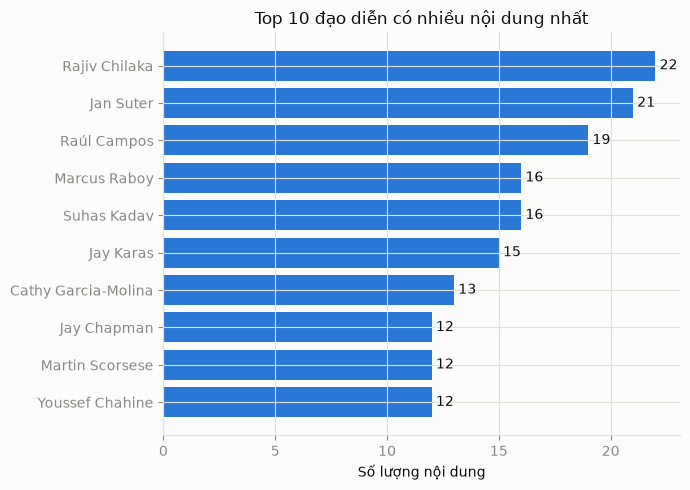

In [30]:
directors = df.assign(d=df['director'].str.split(', ')).explode('d')
directors = directors[directors['d'] != 'Unknown']
top_dir = directors['d'].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.barh(top_dir.index, top_dir.values, color=PALETTE[0])
ax.bar_label(bars, padding=3)
ax.set_title('Top 10 đạo diễn có nhiều nội dung nhất')
ax.set_xlabel('Số lượng nội dung')
plt.tight_layout()
plt.show()

**Insight:** Đạo diễn trong kho nội dung Netflix khá phân tán: người dẫn đầu là Rajiv Chilaka cũng chỉ có 22 tiêu đề, và không đạo diễn nào vượt quá 25 tiêu đề trên tổng số khoảng 8.800. Các đạo diễn trong top 10 chủ yếu thuộc hai nhóm có định dạng ngắn, dễ làm thành nhiều tiêu đề: **stand-up comedy** (Jan Suter, Raúl Campos, Marcus Raboy, Jay Karas, Jay Chapman) và **hoạt hình thiếu nhi Ấn Độ** (Rajiv Chilaka, Suhas Kadav). Chỉ ba người còn lại là đạo diễn phim điện ảnh (Cathy Garcia-Molina, Martin Scorsese, Youssef Chahine). Vì vậy, thứ hạng này phản ánh định dạng nội dung nhiều hơn là mức độ nổi tiếng của đạo diễn.

### 6.7. Quốc gia nào có nhiều nội dung nhất?

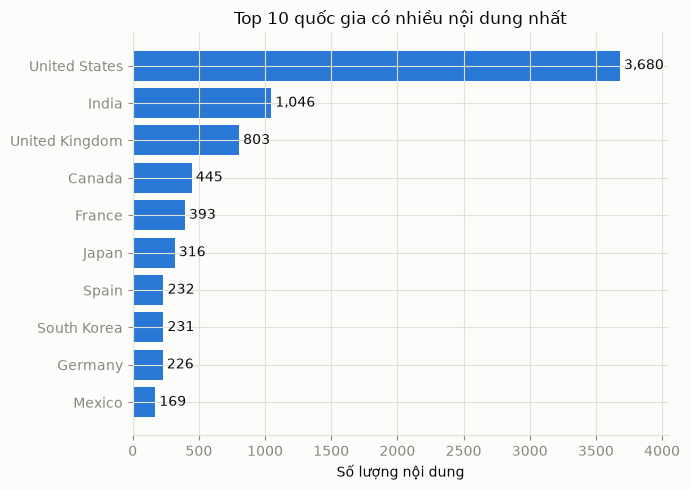

Tiêu đề có thông tin quốc gia: 7961


In [31]:
countries = df.assign(c=df['country'].str.split(', ')).explode('c')
countries = countries[countries['c'] != 'Unknown']
top_c = countries['c'].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.barh(top_c.index, top_c.values, color=PALETTE[0])
ax.bar_label(bars, labels=[f'{v:,}' for v in top_c.values], padding=3)
ax.margins(x=0.1)
ax.set_title('Top 10 quốc gia có nhiều nội dung nhất')
ax.set_xlabel('Số lượng nội dung')
plt.tight_layout()
plt.show()

known = countries.loc[countries['c'] != 'Unknown', 'show_id'].nunique()
print('Tiêu đề có thông tin quốc gia:', known)

**Insight:** Trong 7.961 tiêu đề có thông tin quốc gia, Mỹ áp đảo với **3.680 tiêu đề (~46,2%)**, gấp 3,5 lần quốc gia đứng thứ hai và gần bằng 9 quốc gia còn lại trong top 10 cộng lại (3.861). **Ấn Độ đứng thứ 2** (1.046, ~13,1%), vượt cả Anh (803), là quốc gia ngoài phương Tây duy nhất trong top 3. Top 10 có 3 nước châu Á (Ấn Độ, Nhật Bản, Hàn Quốc) và 1 nước Mỹ Latinh (Mexico), cho thấy kho nội dung có sự đa dạng nhất định ngoài thị trường nói tiếng Anh. Tuy vậy, từ vị trí thứ 4 trở đi, mỗi nước chỉ đóng góp dưới 450 tiêu đề.

### 6.8. Từ khóa phổ biến nhất trong mô tả

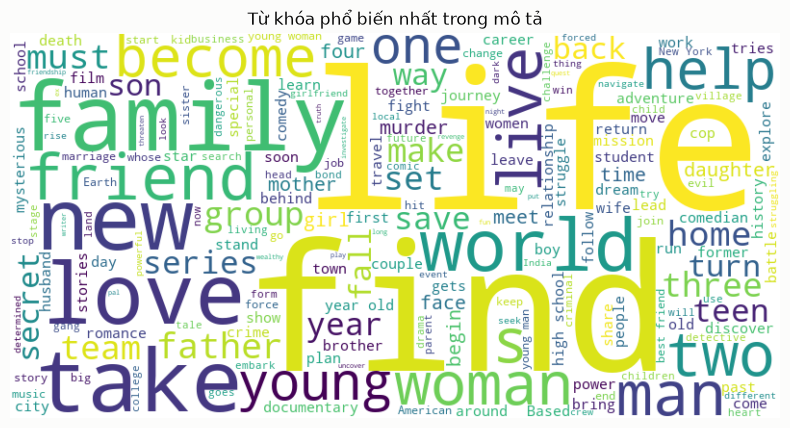

In [32]:
from wordcloud import WordCloud

# Nối toàn bộ mô tả thành 1 chuỗi; WordCloud tự bỏ stopwords tiếng Anh có sẵn
# và tự gộp số ít/số nhiều (normalize_plurals=True, mặc định)
text = ' '.join(df['description'])
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Từ khóa phổ biến nhất trong mô tả')
plt.axis('off')
plt.show()


**Insight:** Các từ nổi bật nhất trong mô tả là **life, family, love, world** và các động từ hành trình như **find, take, become, save**. Mô tả trên Netflix thường giới thiệu nội dung như một câu chuyện về cuộc sống và hành trình của nhân vật. Các từ khóa có thể chia thành vài nhóm chủ đề chính:

- **Gia đình & quan hệ**: family, father, mother, son, daughter, wife, husband, friend, love. Đây là nhóm lớn và phổ biến nhất.
- **Tuổi trẻ & trưởng thành**: young, teen, high school, student, girl, boy.
- **Tội phạm & bí ẩn**: secret, murder, mysterious, crime, detective, cop, criminal.
- **Phiêu lưu & hành động**: world, adventure, mission, battle, fight, save, journey.

Nhìn chung, kho nội dung Netflix được quảng bá chủ yếu qua yếu tố con người và cảm xúc (gia đình, tình yêu, trưởng thành), trong khi các yếu tố kịch tính như tội phạm và phiêu lưu xuất hiện ít nổi bật hơn.

## 7. Kết luận & Đề xuất

### 7.1. Các phát hiện chính
- Movie chiếm đa số kho nội dung. Movie chiếm 69,7% (6.126 tiêu đề), gấp khoảng 2,3 lần TV Show (2.664). Movie chủ yếu dài 90–110 phút. Phần lớn TV Show chỉ có 1 mùa, nên kho series của Netflix nghiêng về series ngắn.
- Nội dung hướng tới người trưởng thành. TV-MA (36%) và TV-14 (25%) là hai rating phổ biến nhất. Nhóm Adults chiếm 45,6%, trong khi nội dung dành cho trẻ nhỏ (TV-Y, TV-G, G) chỉ chiếm 6,5%.
- Kho nội dung được xây dựng chủ yếu từ 2016. Giai đoạn 2016–2021 chiếm 98,4% tổng số tiêu đề, đỉnh là năm 2019 (2.016 tiêu đề). Năm 2021 (dữ liệu đến tháng 9) đạt khoảng 166 tiêu đề/tháng, gần bằng mức đỉnh, tức tốc độ bổ sung không giảm.
- Không có mùa vụ rõ rệt theo thể loại. Tỷ lệ bổ sung theo tháng của các thể loại chỉ dao động quanh mức trung bình là 8,3%. Tháng 2 thấp nhất, một phần vì ít ngày hơn.
- Mỹ áp đảo, nhưng Ấn Độ và châu Á nổi lên. Mỹ chiếm 46,2% số tiêu đề có thông tin quốc gia. Ấn Độ đứng thứ 2 (13,1%), vượt Anh. Top 10 có 3 nước châu Á.
- Nội dung được quảng bá qua con người và cảm xúc. Từ khóa phổ biến xoay quanh gia đình, tình yêu, tuổi trẻ và hành trình của nhân vật.

### 7.2. Đề xuất
- Xem xét mở rộng nội dung cho trẻ nhỏ. Chỉ 6,5% kho dành cho trẻ nhỏ. Nên đối chiếu thêm với tỷ lệ tài khoản có hồ sơ trẻ em trước khi quyết định.
- Tiếp tục mở rộng nội dung quốc tế, đặc biệt là châu Á vì đây là khu vực có tệp khách hàng tiềm năng. Ấn Độ, Nhật Bản và Hàn Quốc đã có mặt trong top 10. Nên phân tích thêm xu hướng theo năm của các nước này để xem đây có phải nhóm đang tăng trưởng không.
- Đánh giá chiến lược duy trì series. Phần lớn series chỉ có 1 mùa. Nên kết hợp với dữ liệu lượt xem để biết series ngắn là do chủ đích hay do bị huỷ, từ đó cân nhắc gia hạn các series có hiệu quả tốt.
- Tận dụng các định dạng chi phí thấp. Stand-up comedy và hoạt hình dạng ngắn giúp tăng số lượng tiêu đề nhanh. Có thể tiếp tục khai thác nếu hiệu quả người xem tương xứng.
- Lịch phát hành linh hoạt. Vì không có mùa vụ rõ rệt theo thể loại, việc phát hành có thể dựa trên chiến dịch marketing hơn là theo mùa. Riêng nội dung gia đình vào cuối năm có thể thử nghiệm thêm.

### 7.3. Giới hạn của dữ liệu
- Dữ liệu chỉ tính đến khoảng 09/2021 (dựa trên `date_added` max) nên số liệu năm 2021 không đại diện cho cả năm.
- `release_year` chỉ có năm, không có tháng, nên không dùng được cho phân tích mùa vụ theo năm phát hành gốc.
- **Thời lượng không đồng nhất đơn vị:** Movie tính bằng phút, TV Show tính bằng số mùa, không có số tập. Vì vậy không so sánh được tổng thời lượng giữa hai loại.
- ~30% dòng thiếu `director`, ~9% thiếu `country` — được gán "Unknown", có thể làm lệch nhẹ thứ hạng đạo diễn/quốc gia nếu tỷ lệ thiếu phân bố không đều giữa các nhóm.